# EDA - Datos Preprocesados de Reddit



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [3]:
csv_path = '../data/preprocesada/reddit_unified_2025.csv'

df = pd.read_csv(csv_path)
df['created_at'] = pd.to_datetime(df['created_at'])

print(f"Registros cargados: {len(df):,}")
print(f"\nForma del DataFrame: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()


Registros cargados: 19,391

Forma del DataFrame: (19391, 2)

Columnas: ['text', 'created_at']

Primeras filas:


,text,created_at
0,¿El S&P 500 a largo plazo sigue valiendo la pe...,2025-01-05 00:03:17
1,"Claro, si quiero ver algo a más corto plazo (1...",2025-01-05 00:09:12
2,Por la apreciación del peso (a.k.a. bajas del ...,2025-01-05 00:11:17
3,Yo dejaría ahi un fondo en dólares que no pien...,2025-01-05 00:12:00
4,Todavia soy muy noob en esto pero merval a cor...,2025-01-05 00:12:16


In [4]:
print("="*60)
print("INFORMACIÓN GENERAL")
print("="*60)

print(f"\nRango de fechas:")
print(f"  Desde: {df['created_at'].min()}")
print(f"  Hasta: {df['created_at'].max()}")
print(f"  Total de días: {(df['created_at'].max() - df['created_at'].min()).days + 1}")

print(f"\nEstadísticas básicas:")
print(f"  Total registros: {len(df):,}")
print(f"  Registros únicos: {df['text'].nunique():,}")
print(f"  Duplicados: {len(df) - df['text'].nunique():,}")


INFORMACIÓN GENERAL

Rango de fechas:
  Desde: 2025-01-05 00:03:17
  Hasta: 2025-11-18 00:07:57
  Total de días: 318

Estadísticas básicas:
  Total registros: 19,391
  Registros únicos: 19,288
  Duplicados: 103


In [5]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['date'] = df['created_at'].dt.date

print("="*60)
print("ANÁLISIS DE TEXTO")
print("="*60)

print(f"\nLongitud de texto:")
print(df['text_length'].describe())

print(f"\nCantidad de palabras:")
print(df['word_count'].describe())


ANÁLISIS DE TEXTO

Longitud de texto:
count    19391.000000
mean       390.082255
std        591.916199
min          3.000000
25%        124.000000
50%        236.000000
75%        453.500000
max      31950.000000
Name: text_length, dtype: float64

Cantidad de palabras:
count    19391.000000
mean        67.260172
std         89.981394
min          1.000000
25%         22.000000
50%         42.000000
75%         80.000000
max       2442.000000
Name: word_count, dtype: float64


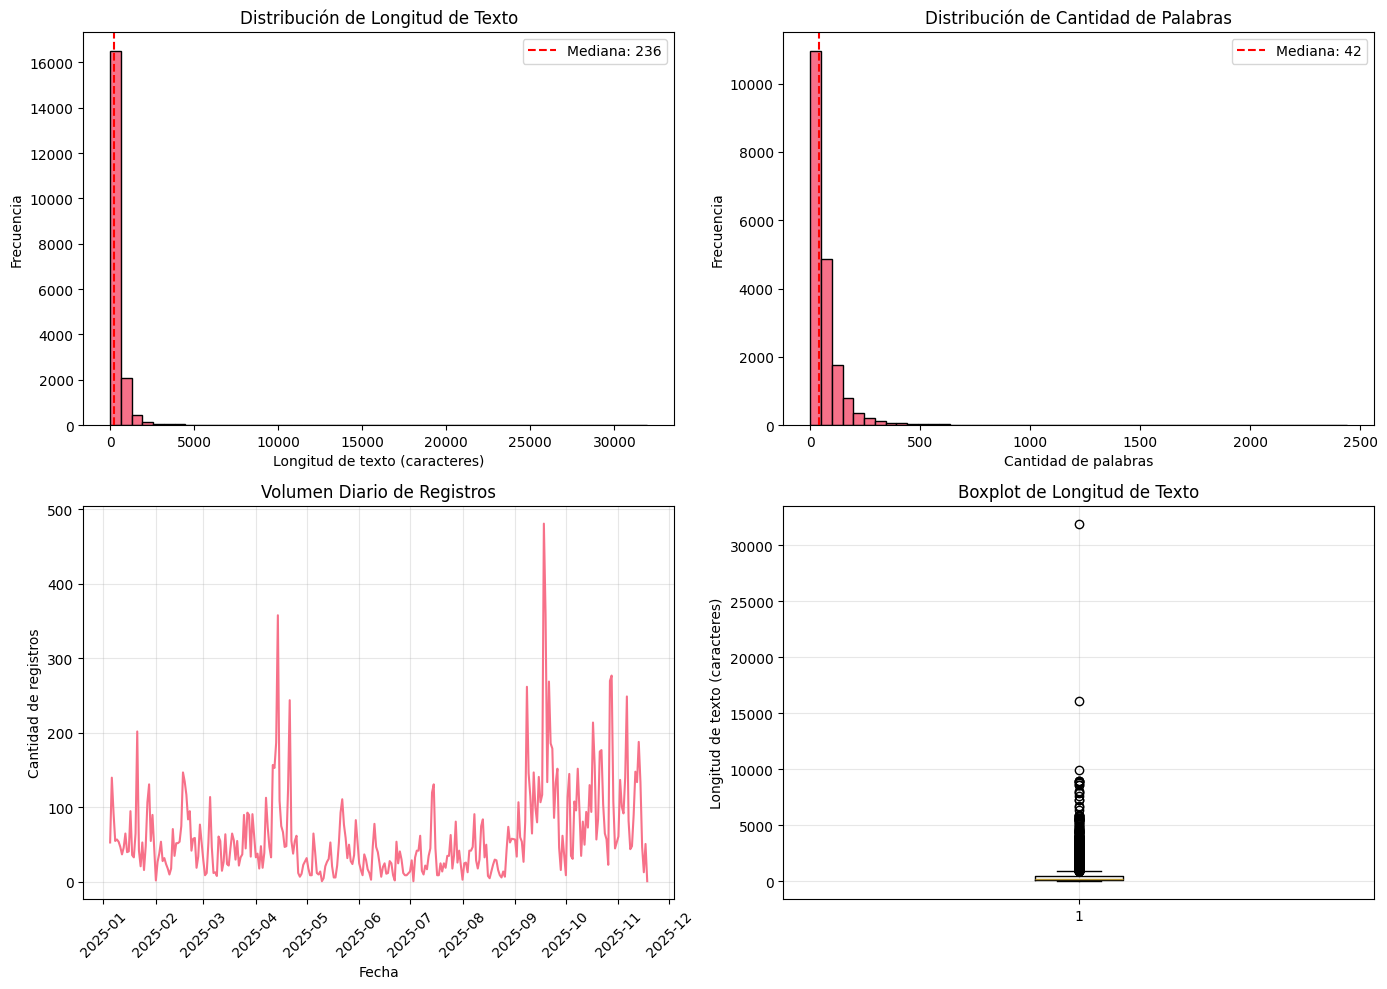

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de longitud de texto
axes[0, 0].hist(df['text_length'], bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Longitud de texto (caracteres)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Longitud de Texto')
axes[0, 0].axvline(df['text_length'].median(), color='r', linestyle='--', label=f'Mediana: {df["text_length"].median():.0f}')
axes[0, 0].legend()

# Distribución de cantidad de palabras
axes[0, 1].hist(df['word_count'], bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Cantidad de palabras')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Cantidad de Palabras')
axes[0, 1].axvline(df['word_count'].median(), color='r', linestyle='--', label=f'Mediana: {df["word_count"].median():.0f}')
axes[0, 1].legend()

# Volumen diario
daily_counts = df.groupby('date').size()
axes[1, 0].plot(daily_counts.index, daily_counts.values, linewidth=1.5)
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].set_ylabel('Cantidad de registros')
axes[1, 0].set_title('Volumen Diario de Registros')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Boxplot de longitud
axes[1, 1].boxplot(df['text_length'], vert=True)
axes[1, 1].set_ylabel('Longitud de texto (caracteres)')
axes[1, 1].set_title('Boxplot de Longitud de Texto')
axes[1, 1].grid(True, alpha=0.3)    

plt.tight_layout()
plt.show()


In [7]:
print("="*60)
print("ANÁLISIS TEMPORAL")
print("="*60)

daily_stats = df.groupby('date').agg({
    'text': 'count',
    'text_length': ['mean', 'median'],      
    'word_count': ['mean', 'median']
}).round(2)

daily_stats.columns = ['cantidad', 'long_media', 'long_mediana', 'palabras_media', 'palabras_mediana']
daily_stats = daily_stats.sort_index()

print(f"\nEstadísticas diarias (primeros 10 días):")
print(daily_stats.head(10))

print(f"\nEstadísticas diarias (últimos 10 días):")
print(daily_stats.tail(10))


ANÁLISIS TEMPORAL

Estadísticas diarias (primeros 10 días):
            cantidad  long_media  long_mediana  palabras_media  \
date                                                             
2025-01-05        53      388.53         245.0           70.45   
2025-01-06       140      594.78         405.0          101.91   
2025-01-07        93      437.06         370.0           76.15   
2025-01-08        55      398.62         259.0           69.24   
2025-01-09        57      278.28         224.0           51.14   
2025-01-10        54      378.61         160.0           60.06   
2025-01-11        47      457.89         294.0           76.38   
2025-01-12        37      454.57         319.0           80.41   
2025-01-13        46      471.80         280.5           74.67   
2025-01-14        65      399.97         281.0           70.09   

            palabras_mediana  
date                          
2025-01-05              46.0  
2025-01-06              72.5  
2025-01-07             

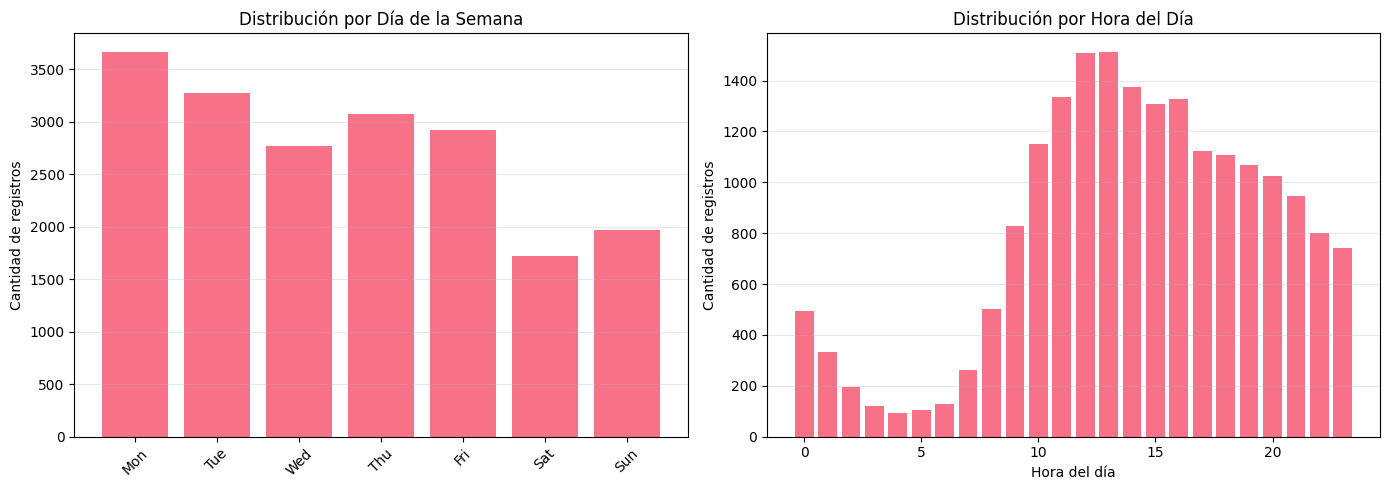

In [8]:
df['day_of_week'] = df['created_at'].dt.day_name()
df['hour'] = df['created_at'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución por día de la semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order, fill_value=0)
axes[0].bar(range(len(day_counts)), day_counts.values)
axes[0].set_xticks(range(len(day_counts)))
axes[0].set_xticklabels([d[:3] for d in day_counts.index], rotation=45)
axes[0].set_ylabel('Cantidad de registros')
axes[0].set_title('Distribución por Día de la Semana')
axes[0].grid(True, alpha=0.3, axis='y')

# Distribución por hora
hour_counts = df['hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values)
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Cantidad de registros')
axes[1].set_title('Distribución por Hora del Día')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [9]:
print("="*60)
print("RESUMEN FINAL")
print("="*60)

print(f"\nTotal de registros: {len(df):,}")
print(f"Rango temporal: {df['created_at'].min().date()} a {df['created_at'].max().date()}")
print(f"Días con datos: {df['date'].nunique()}")
print(f"Promedio diario: {len(df) / df['date'].nunique():.1f} registros")
print(f"\nLongitud promedio de texto: {df['text_length'].mean():.0f} caracteres")
print(f"Palabras promedio: {df['word_count'].mean():.1f} palabras")
print(f"\nDía más activo: {daily_stats['cantidad'].idxmax()} ({daily_stats['cantidad'].max():.0f} registros)")
print(f"Día menos activo: {daily_stats['cantidad'].idxmin()} ({daily_stats['cantidad'].min():.0f} registros)")


RESUMEN FINAL

Total de registros: 19,391
Rango temporal: 2025-01-05 a 2025-11-18
Días con datos: 308
Promedio diario: 63.0 registros

Longitud promedio de texto: 390 caracteres
Palabras promedio: 67.3 palabras

Día más activo: 2025-09-18 (481 registros)
Día menos activo: 2025-05-10 (1 registros)
